In [3]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx
from itertools import combinations
import time

# Load IMDB-BINARY dataset
imdb_dataset = TUDataset(root='./data', name='IMDB-BINARY')
print(f"IMDB-BINARY: {len(imdb_dataset)} graphs")

# Load COLLAB dataset  
collab_dataset = TUDataset(root='./data', name='COLLAB')
print(f"COLLAB: {len(collab_dataset)} graphs")

# Examine a sample graph
sample_graph = imdb_dataset[0]
print(f"\nSample graph statistics:")
print(f"  Nodes: {sample_graph.num_nodes}")
print(f"  Edges: {sample_graph.num_edges}")

IMDB-BINARY: 1000 graphs
COLLAB: 5000 graphs

Sample graph statistics:
  Nodes: 20
  Edges: 146


In [4]:
def is_clique(nodes, A):
    """
    Check if a set of nodes forms a clique.
    """
    if len(nodes) <= 1:
        return True
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if A[nodes[i], nodes[j]] == 0:
                return False
    return True

In [5]:
def brute_force_max_clique(A):
    """
    Find the maximum clique by brute force enumeration.
    """
    n = A.shape[0]
    nodes = list(range(n))
    for k in range(n, 0, -1):
        for subset in combinations(nodes, k):
            if is_clique(subset, A):
                return list(subset)
    return []

In [6]:
def test_brute_force():
    """
    Test brute force on small graphs and measure computation time.
    """
    # Create a simple test graph: triangle (clique of size 3) plus one extra node
    # Nodes 0, 1, 2 form a triangle; node 3 connects only to node 2
    A = np.array([
        [0, 1, 1, 0],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [0, 0, 1, 0]
    ], dtype=float)
    
    start = time.time()
    clique = brute_force_max_clique(A)
    elapsed = time.time() - start
    
    print(f"Maximum clique: {clique}")
    print(f"Clique size: {len(clique)}")
    print(f"Time: {elapsed:.4f} seconds")
    
    # Verify it's actually a clique
    print(f"Is valid clique: {is_clique(clique, A)}")

test_brute_force()

Maximum clique: [0, 1, 2]
Clique size: 3
Time: 0.0000 seconds
Is valid clique: True


In [7]:
def evaluate_brute_force_on_dataset(dataset, max_graphs=10, max_nodes=25):
    """
    Evaluate brute force on dataset (only small graphs).
    """
    results = []
    
    for i in range(min(max_graphs, len(dataset))):
        data = dataset[i]
        
        if data.num_nodes > max_nodes:
            # print(f"Graph {i}: Skipping (too large: {data.num_nodes} nodes)")
            continue
        
        G = to_networkx(data, to_undirected=True)
        A = nx.adjacency_matrix(G).toarray().astype(float)
        
        start = time.time()
        clique = brute_force_max_clique(A)
        elapsed = time.time() - start
        
        results.append((i, len(clique), elapsed))
    
    return results

print("\nEvaluating brute force on IMDB-BINARY:")
imdb_results = evaluate_brute_force_on_dataset(imdb_dataset)
print("\nEvaluating brute force on COLLAB:") 
collab_results = evaluate_brute_force_on_dataset(collab_dataset) 
print("\nIMDB-BINARY results (graph index, clique size, time):") 
for res in imdb_results: 
    print(res) 


Evaluating brute force on IMDB-BINARY:

Evaluating brute force on COLLAB:

IMDB-BINARY results (graph index, clique size, time):
(0, 9, 0.3566169738769531)
(2, 10, 0.5987167358398438)
(4, 9, 0.002972841262817383)
(6, 12, 9.298324584960938e-06)
(7, 9, 0.0036809444427490234)
(8, 18, 1.5735626220703125e-05)
(9, 12, 8.821487426757812e-06)


In [8]:
def motzkin_straus_objective(x, A):
    """
    Compute the Motzkin-Straus objective f(x) = x^T A x
    """
    return float(x.T @ A @ x)


def regularized_objective(x, A):
    """
    Compute the regularized objective f_hat(x) = x^T (A + 0.5*I) x
    """
    n = A.shape[0]
    A_reg = A + 0.5 * np.eye(n)
    return float(x.T @ A_reg @ x)

In [10]:
def verify_motzkin_straus():
    """
    Verify the Motzkin-Straus theorem on test graphs.
    """
    # Test 1: Triangle (K3) - maximum clique size 3
    A1 = np.array([
        [0, 1, 1],
        [1, 0, 1],
        [1, 1, 0]
    ], dtype=float)

    clique1 = brute_force_max_clique(A1)
    k1 = len(clique1)
    x1 = np.zeros(A1.shape[0])
    x1[clique1] = 1.0 / k1
    f1 = motzkin_straus_objective(x1, A1)
    print("Test 1 (K3):")
    print("  Clique:", clique1)
    print("  f(x*) =", f1, " 1 - 1/k =", 1 - 1 / k1)

    # Test 2: Square with diagonal - maximum clique size 3
    A2 = np.array([
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [1, 0, 1, 0]
    ], dtype=float)

    clique2 = brute_force_max_clique(A2)
    k2 = len(clique2)
    x2 = np.zeros(A2.shape[0])
    x2[clique2] = 1.0 / k2
    f2 = motzkin_straus_objective(x2, A2)
    print("Test 2 (Square + diagonal):")
    print("  Clique:", clique2)
    print("  f(x*) =", f2, " 1 - 1/k =", 1 - 1 / k2)

    # Test 3: Cherry graph - verify spurious solutions
    A3 = np.array([
        [0, 0, 1],
        [0, 0, 1],
        [1, 1, 0]
    ], dtype=float)

    x_true = np.array([0.5, 0.0, 0.5])
    x_spur = np.array([0.25, 0.25, 0.5])

    f_true = motzkin_straus_objective(x_true, A3)
    f_spur = motzkin_straus_objective(x_spur, A3)

    f_true_reg = regularized_objective(x_true, A3)
    f_spur_reg = regularized_objective(x_spur, A3)

    print("Test 3 (Cherry):")
    print("  f(x_true) =", f_true, " f(x_spur) =", f_spur)
    print("  f_hat(x_true) =", f_true_reg, " f_hat(x_spur) =", f_spur_reg)

verify_motzkin_straus()

Test 1 (K3):
  Clique: [0, 1, 2]
  f(x*) = 0.6666666666666666  1 - 1/k = 0.6666666666666667
Test 2 (Square + diagonal):
  Clique: [0, 1, 2]
  f(x*) = 0.6666666666666666  1 - 1/k = 0.6666666666666667
Test 3 (Cherry):
  f(x_true) = 0.5  f(x_spur) = 0.5
  f_hat(x_true) = 0.75  f_hat(x_spur) = 0.6875


In [15]:
def replicator_dynamics(A, max_iter=1000, tol=1e-12, use_regularization=True):
    """
    Run Replicator Dynamics to find the maximum clique.
    
    This follows the formulation from Pelillo et al.:
    x_new = x * (A @ x)
    x_new = x_new / x_new.sum()
    """
    n = A.shape[0]
    
    # Regularization (Pelillo et al. modification to avoid spurious solutions)
    if use_regularization:
        A_reg = A + 0.5 * np.eye(n)
    else:
        A_reg = A.copy()
    
    # Initialize at barycenter
    x = np.ones(n) / n
    
    history = {
        'objectives': [x @ A_reg @ x],
        'iterations': 0
    }
    
    for t in range(max_iter):
        x_old = x.copy()
        
        # Pelillo RD update
        x = x * (A_reg @ x)
        x = x / x.sum()
        
        # Record objective
        obj = x @ A_reg @ x
        history['objectives'].append(obj)
        history['iterations'] = t + 1
        
        # Check convergence
        if np.max(np.abs(x - x_old)) < tol:
            break
    
    return x, history

In [16]:
def decode_clique(x, A, threshold=1e-6):
    """
    Extract the maximum clique from the RD solution.
    
    Strategy: 
    1. Sort nodes by x value (descending)
    2. Greedily add nodes that maintain clique property
    """
    n = A.shape[0]
    
    # Sort nodes by x value (descending)
    indices = np.argsort(-x)
    
    clique = []
    
    for i in indices:
        # Stop if x value is below threshold and we already have some nodes
        if x[i] < threshold and len(clique) > 0:
            break
        
        # Check if node i can be added to the current clique
        can_extend = True
        for j in clique:
            if A[i, j] == 0:
                can_extend = False
                break
        
        if can_extend:
            clique.append(i)
    
    return clique

In [17]:
def visualize_rd(A, graph_name="Test Graph"):
    """
    Run RD and create visualization of convergence.
    """
    x_final, history = replicator_dynamics(A)
    n = A.shape[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot 1: Objective value f(x(t)) over time
    axes[0].plot(history['objectives'], 'b-', linewidth=2)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('$f(x(t))$', fontsize=12)
    axes[0].set_title('Objective Value (Monotonic Increase)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Final x values as bar chart
    axes[1].bar(range(n), x_final, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Node', fontsize=12)
    axes[1].set_ylabel('$x_i$', fontsize=12)
    axes[1].set_title('Final Simplex Point', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Identify clique and show distribution
    clique = decode_clique(x_final, A)
    clique_set = set(clique)
    colors = ['red' if i in clique_set else 'lightblue' for i in range(n)]
    axes[2].bar(range(n), x_final, color=colors, edgecolor='black')
    axes[2].set_xlabel('Node', fontsize=12)
    axes[2].set_ylabel('$x_i$', fontsize=12)
    axes[2].set_title(f'Clique (red): {clique}', fontsize=12)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f"Replicator Dynamics: {graph_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return x_final

In [18]:
def evaluate_rd_on_dataset(dataset, dataset_name, num_graphs=50):
    """
    Evaluate Replicator Dynamics on a dataset.
    """
    results = []
    
    for i in range(min(num_graphs, len(dataset))):
        data = dataset[i]
        G = to_networkx(data, to_undirected=True)
        A = nx.adjacency_matrix(G).toarray().astype(float)
        
        start_time = time.time()
        x_final, history = replicator_dynamics(A, max_iter=1000)
        clique = decode_clique(x_final, A)
        elapsed = time.time() - start_time
        
        # Verify it's a valid clique
        valid = is_clique(clique, A)
        
        results.append({
            'graph_idx': i,
            'num_nodes': data.num_nodes,
            'clique_size': len(clique),
            'clique': clique,
            'valid': valid,
            'time': elapsed,
            'iterations': history['iterations']
        })
        
        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{num_graphs} graphs")
    
    # Summary statistics
    sizes = [r['clique_size'] for r in results]
    times = [r['time'] for r in results]
    valid_count = sum(r['valid'] for r in results)
    
    print(f"\n{dataset_name} Results:")
    print(f"  Mean clique size: {np.mean(sizes):.2f} ± {np.std(sizes):.2f}")
    print(f"  Mean time: {np.mean(times):.4f} seconds")
    print(f"  Valid cliques: {valid_count}/{len(results)}")
    
    return results

TEST 1: Visualizing RD on triangle + extra node


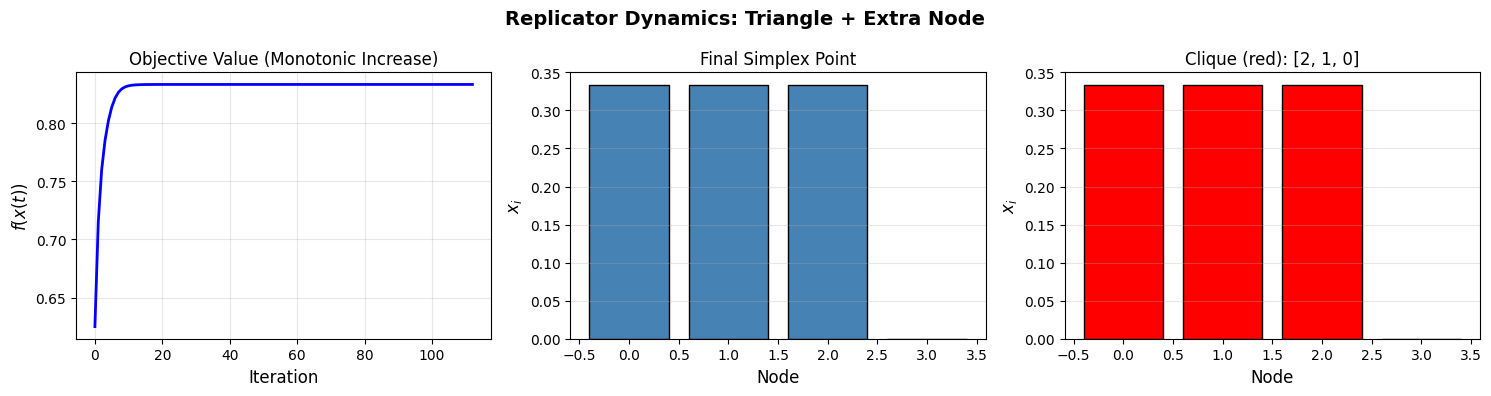


Final x: [3.33333333e-01 3.33333333e-01 3.33333333e-01 1.76038316e-44]
Decoded clique: [2, 1, 0]
Is valid clique: True

TEST 2: Visualizing RD on K3 (complete triangle)


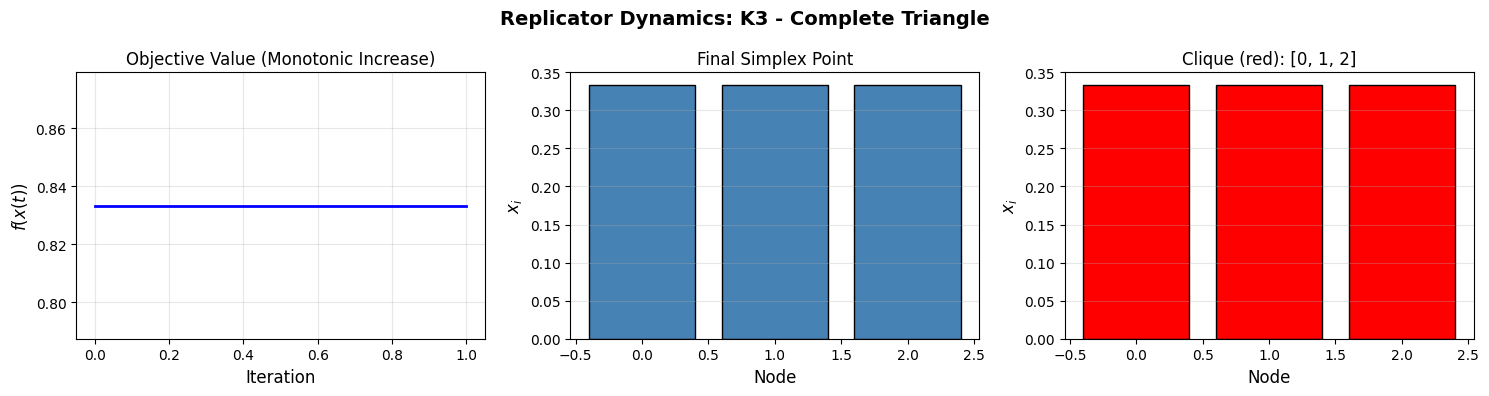


Final x: [0.33333333 0.33333333 0.33333333]
Decoded clique: [0, 1, 2]
Is valid clique: True

TEST 3: Evaluating RD on IMDB-BINARY (first 5 graphs)

IMDB-BINARY Results:
  Mean clique size: 9.20 ± 1.33
  Mean time: 0.0026 seconds
  Valid cliques: 5/5

TEST 4: Evaluating RD on COLLAB (first 5 graphs)

COLLAB Results:
  Mean clique size: 39.60 ± 4.84
  Mean time: 0.0045 seconds
  Valid cliques: 5/5

SUMMARY

IMDB-BINARY RD Results:
  Graph 0: clique_size=9, valid=True, time=0.0034s, iter=377
  Graph 1: clique_size=11, valid=True, time=0.0029s, iter=460
  Graph 2: clique_size=10, valid=True, time=0.0024s, iter=415
  Graph 3: clique_size=7, valid=True, time=0.0021s, iter=354
  Graph 4: clique_size=9, valid=True, time=0.0021s, iter=372

COLLAB RD Results:
  Graph 0: clique_size=45, valid=True, time=0.0001s, iter=1
  Graph 1: clique_size=36, valid=True, time=0.0082s, iter=1000
  Graph 2: clique_size=42, valid=True, time=0.0081s, iter=1000
  Graph 3: clique_size=32, valid=True, time=0.0001s, 

In [19]:
# Test 1: Visualize RD on the triangle + extra node graph
print("="*60)
print("TEST 1: Visualizing RD on triangle + extra node")
print("="*60)
A_test = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [0, 0, 1, 0]
], dtype=float)

x_final = visualize_rd(A_test, "Triangle + Extra Node")
print(f"\nFinal x: {x_final}")
clique = decode_clique(x_final, A_test)
print(f"Decoded clique: {clique}")
print(f"Is valid clique: {is_clique(clique, A_test)}")

# Test 2: Visualize RD on K3 (complete triangle)
print("\n" + "="*60)
print("TEST 2: Visualizing RD on K3 (complete triangle)")
print("="*60)
A_k3 = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], dtype=float)

x_final = visualize_rd(A_k3, "K3 - Complete Triangle")
print(f"\nFinal x: {x_final}")
clique = decode_clique(x_final, A_k3)
print(f"Decoded clique: {clique}")
print(f"Is valid clique: {is_clique(clique, A_k3)}")

# Test 3: Evaluate RD on small subset of IMDB
print("\n" + "="*60)
print("TEST 3: Evaluating RD on IMDB-BINARY (first 5 graphs)")
print("="*60)
imdb_rd_results = evaluate_rd_on_dataset(imdb_dataset, "IMDB-BINARY", num_graphs=5)

# Test 4: Evaluate RD on small subset of COLLAB
print("\n" + "="*60)
print("TEST 4: Evaluating RD on COLLAB (first 5 graphs)")
print("="*60)
collab_rd_results = evaluate_rd_on_dataset(collab_dataset, "COLLAB", num_graphs=5)

# Summary comparison
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("\nIMDB-BINARY RD Results:")
for r in imdb_rd_results:
    print(f"  Graph {r['graph_idx']}: clique_size={r['clique_size']}, valid={r['valid']}, time={r['time']:.4f}s, iter={r['iterations']}")

print("\nCOLLAB RD Results:")
for r in collab_rd_results:
    print(f"  Graph {r['graph_idx']}: clique_size={r['clique_size']}, valid={r['valid']}, time={r['time']:.4f}s, iter={r['iterations']}")